In [1]:
# Importing data and gettting informations

import pandas as pd
import numpy as nu

df_mtC02 = pd.read_csv('GCB2022v27_MtCO2_flat.csv')
df_percapita = pd.read_csv('GCB2022v27_percapita_flat.csv')

df_mtC02.info()
df_percapita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             63104 non-null  object 
 1   ISO 3166-1 alpha-3  61472 non-null  object 
 2   Year                63104 non-null  int64  
 3   Total               62904 non-null  float64
 4   Coal                21744 non-null  float64
 5   Oil                 21717 non-null  float64
 6   Gas                 21618 non-null  float64
 7   Cement              20814 non-null  float64
 8   Flaring             21550 non-null  float64
 9   Other               1620 non-null   float64
 10  Per Capita          18974 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 5.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63104 entries, 0 to 63103
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              ---------

<class 'pandas.core.frame.DataFrame'>
Index: 61472 entries, 0 to 63103
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             61472 non-null  object 
 1   ISO 3166-1 alpha-3  61472 non-null  object 
 2   Year                61472 non-null  int64  
 3   Total               61272 non-null  float64
 4   Coal                21660 non-null  float64
 5   Oil                 21633 non-null  float64
 6   Gas                 21534 non-null  float64
 7   Cement              20730 non-null  float64
 8   Flaring             21466 non-null  float64
 9   Other               1620 non-null   float64
 10  Per Capita          18542 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 5.6+ MB


<Axes: xlabel='Year'>

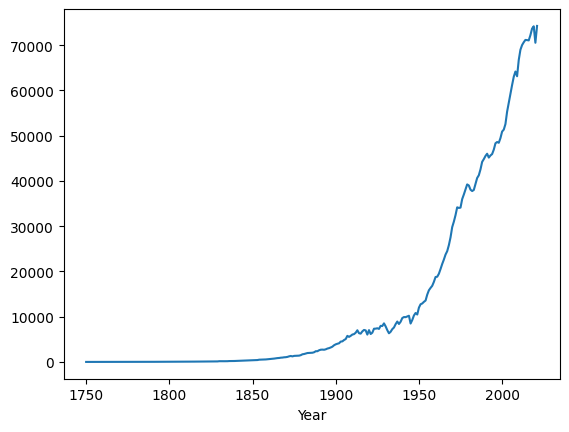

In [6]:
# Removing rows that have null values at ISO Code
df_clean = df_mtC02.dropna(subset=['ISO 3166-1 alpha-3'])

# Consulting if everything works
df_clean.info()

#Doing a filter to show only the last 30 years
df_recent = df_clean['Year'] >= 1990

# Nations existents
df_clean['Country'].unique()

#Total Emissions by Year
df_clean.groupby('Year')['Total'].sum().plot()



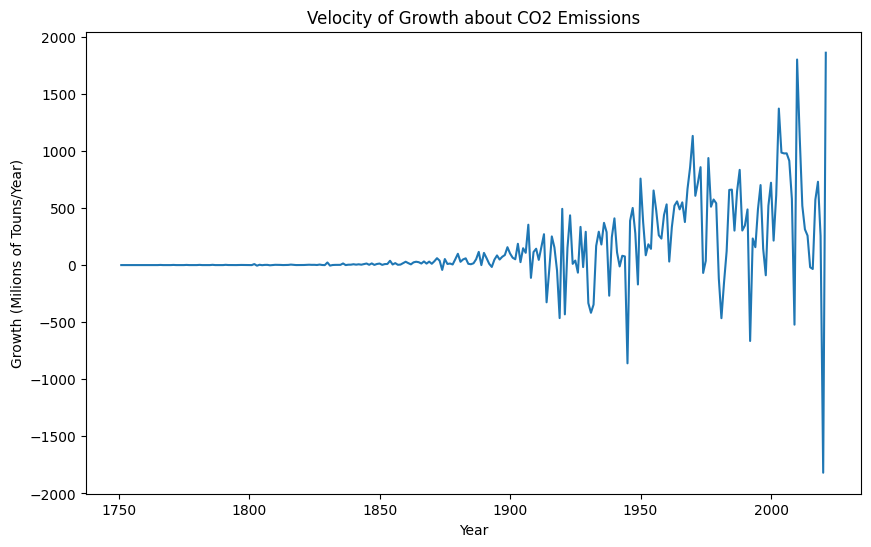

<Figure size 640x480 with 0 Axes>

In [7]:
# Isolating the DataFrame only Global
df_global = df_clean[df_clean['Country'] == 'Global']

# Calculate the difference between years
growth_by_year = nu.diff(df_global['Total'].values)

# Using matplotlib to create a graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_global['Year'].values[1:], growth_by_year)
plt.title('Velocity of Growth about CO2 Emissions')
plt.xlabel('Year')
plt.ylabel('Growth (Milions of Touns/Year)')
plt.show()
plt.savefig('Velocity of Growth about CO2 Emissions.png')

In [8]:
# Discovering the year with the biggest increase
index_max_increase = nu.argmax(growth_by_year)
year_max_increase = df_global['Year'].values[index_max_increase + 1]

print(f'The year with the biggest increase is {year_max_increase}')


The year with the biggest increase is 2021


In [9]:
# List of nations to compare
countries = ['Brazil', 'China', 'USA']

#Filtering the DataFrame only with these nations
compare_countries = df_clean[df_clean['Country'].isin(countries)]

#Clustering nations and calculating the historical mean of emissions per capita
mean_countries = df_percapita[df_percapita['Country'].isin(countries)].groupby('Country')['Total'].mean()

mean_countries.round(3)

,Total
Country,
Brazil,1.441
China,1.002
USA,11.149


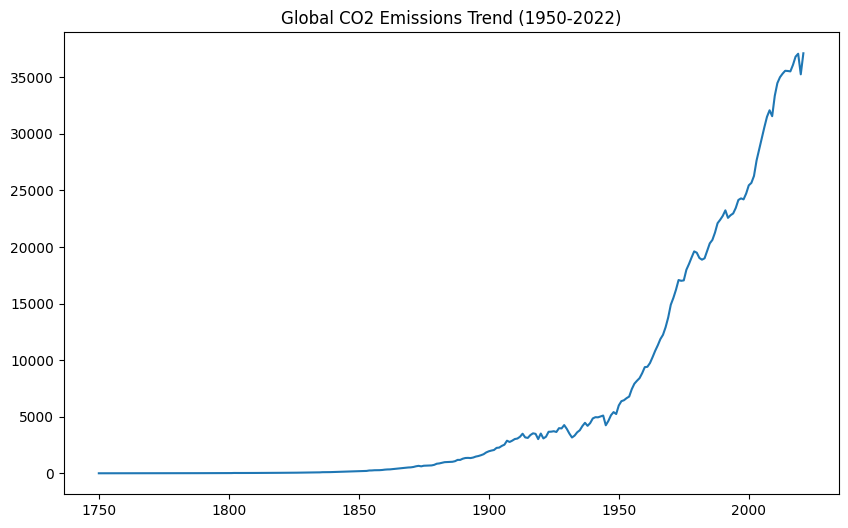

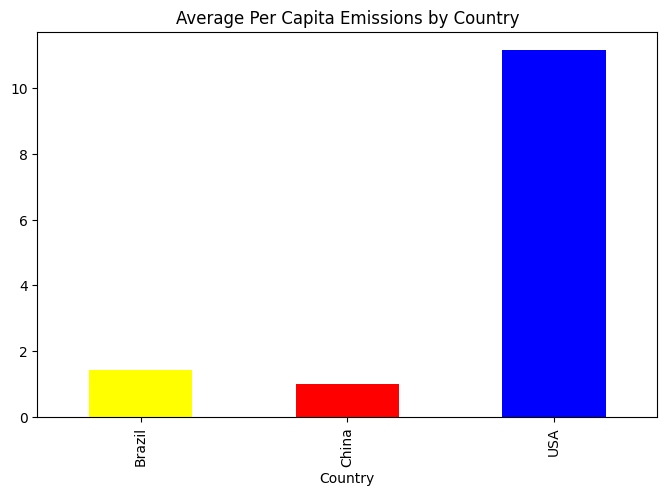

In [11]:
# 1. Save the tendency global graph
plt.figure(figsize=(10, 6))
plt.plot(df_global['Year'], df_global['Total'])
plt.title('Global CO2 Emissions Trend (1950-2022)')
plt.savefig('global_emissions_trend.png') # Salva a imagem
plt.show()

# 2. Save the comparasion graph *bar charsSalvar o gráfico de comparação
plt.figure(figsize=(8, 5))
mean_countries.plot(kind='bar', color=['yellow', 'red', 'blue'])
plt.title('Average Per Capita Emissions by Country')
plt.savefig('comparison_per_capita.png') # Save image
plt.show()